# 03 — Reading a Spectrum: Where Sounds "Live" in Frequency

### Why this notebook exists

Notebook 02 ended with a loose thread, deliberately left unchased: Elissa's isolated
vocal stem seemed to concentrate its energy very differently than any Suno vocal stem
did. Is that a real mixing difference, or is the separation tool doing a worse job on
Suno's synthetic voices? We can't answer that yet — because we don't have the vocabulary
for "where energy lives in frequency" at all.

Every script in this project that mentions "2-5 kHz presence," "low-mid," or "bass" is
leaning on that vocabulary without ever explaining it. This notebook builds it from
scratch, grounded in the project's real audio, so **Notebook 04** can put it to use.

## Setup

New tool this time: `librosa.stft` (Short-Time Fourier Transform) and
`librosa.display`, for turning a waveform into a picture of its frequency content.

In [1]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

DATA_DIR = "../data"
PLOTS_DIR = "../LABS/session_2026-07-29T172033/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

ELISSA_MIX = f"{DATA_DIR}/elisa_maktooba_leek.mp3"
YADAR_MIX  = f"{DATA_DIR}/يا دار مية - 28-07-2026.mp3"

TRACKS = [
    ("Elissa (reference)",  f"{DATA_DIR}/elisa_maktooba_leek.mp3"),
    ("Ya Dar Maya (orig)",  f"{DATA_DIR}/يا دار مية - 28-07-2026.mp3"),
    ("SONG_A",              f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_A.mp3"),
    ("SONG_B",              f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_B.mp3"),
    ("SONG_C",              f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_C.mp3"),
    ("SONG_D",              f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_D.mp3"),
]

print("Setup complete. Tracks registered:", len(TRACKS))

Setup complete. Tracks registered: 6


## A. What does "frequency" even mean?

Every notebook so far has measured **loudness** (RMS/dB) — how big the air-pressure wave
is. Loudness says nothing about **pitch** — how *fast* that wave is wiggling.

A sound's frequency is measured in **Hz (cycles per second)**. A low rumbling bass note
might wiggle 60 times a second (60 Hz). A bright cymbal shimmer might wiggle 8,000 times a
second (8 kHz). Human hearing roughly spans **20 Hz to 20,000 Hz (20 kHz)**, though most
of the musically important information — bass, vocals, most instruments — lives well
below 5 kHz.

Real sounds are never *one* frequency. A sung note, a guitar chord, a kick drum hit — each
is a **mixture** of many frequencies at once, in different proportions. That mixture is
what a "spectrum" describes.

## B. From waveform to spectrum: the FFT

The **Fast Fourier Transform (FFT)** takes a chunk of waveform and answers the question
"how much of each frequency is present in this chunk?" Let's take a single, short window
of Elissa's track and look at both views side by side: the waveform (loudness over time)
and its spectrum (energy over frequency).

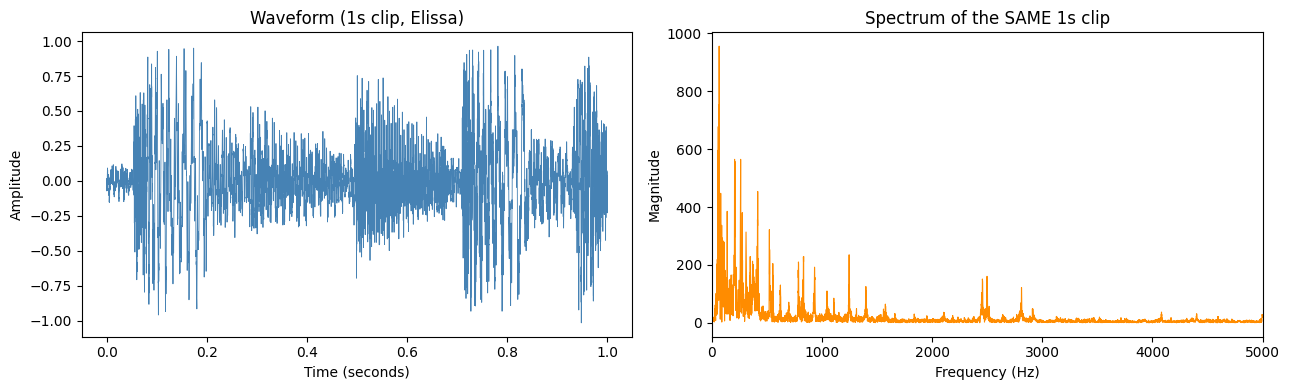

In [2]:
y, sr = librosa.load(ELISSA_MIX, sr=22050, mono=True, offset=45.0, duration=1.0)

# The waveform view (what we've plotted since Notebook 00)
t = np.linspace(0, len(y) / sr, num=len(y))

# The spectrum view: one FFT over the whole 1-second window
spectrum = np.abs(np.fft.rfft(y))
freqs = np.fft.rfftfreq(len(y), d=1.0 / sr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(t, y, linewidth=0.6, color="steelblue")
axes[0].set_title("Waveform (1s clip, Elissa)")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(freqs, spectrum, linewidth=0.8, color="darkorange")
axes[1].set_xlim(0, 5000)
axes[1].set_title("Spectrum of the SAME 1s clip")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/waveform_vs_spectrum.png", dpi=110)
plt.show()

display(Audio(y, rate=sr))

**Same one second of audio, two different questions answered.** The waveform (left)
answers "how loud, moment by moment?" The spectrum (right) answers "which frequencies
make up that sound, added together?" Notice the spectrum isn't smooth — it has peaks at
specific frequencies (the fundamental pitch being sung/played, plus its harmonics) and
falls off toward higher frequencies, which is typical of most music.

## C. From one frame to a spectrogram: adding time back in

A single FFT only describes one static instant. But music changes constantly — a
spectrogram solves this by computing an FFT on many small, overlapping windows in a row,
and stacking them into a single image: **time on the x-axis, frequency on the y-axis,
color = how much energy is at that frequency at that instant.** This is exactly what the
**S**hort-**T**ime **F**ourier **T**ransform (STFT) computes, and it's the same
`librosa.stft` function used throughout this project's separation-quality and reverb
scripts.

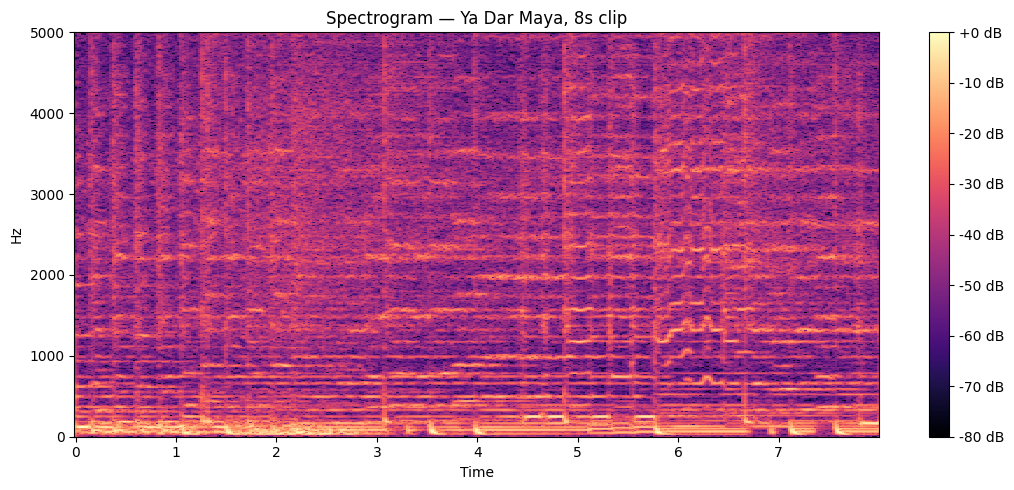

In [3]:
y_clip, sr = librosa.load(YADAR_MIX, sr=22050, mono=True, offset=20.0, duration=8.0)

S = librosa.stft(y_clip, n_fft=2048)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

fig, ax = plt.subplots(figsize=(11, 5))
img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="hz", ax=ax, cmap="magma")
ax.set_ylim(0, 5000)
ax.set_title("Spectrogram — Ya Dar Maya, 8s clip")
fig.colorbar(img, ax=ax, format="%+2.0f dB")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/spectrogram_example.png", dpi=110)
plt.show()

display(Audio(y_clip, rate=sr))

**Listen to the clip while looking at the image.** The bright horizontal bands are
sustained pitches (vocal notes, sustained instrument tones); short vertical smears are
percussive hits (a drum, a pluck) that briefly excite a wide range of frequencies at
once. This is the picture every "spectral profile" plot in the project's earlier scripts
is quietly built from — including the ones in Notebook 04.

## D. Naming frequency bands

Engineers rarely talk about exact Hz numbers. Instead, they group frequencies into named
**bands**, because different instruments and different problems tend to live in
different ranges. These are the exact bands used elsewhere in this project's scripts
(`stem_analysis.py`):

| Band | Range | Typically home to |
|---|---|---|
| Sub | 20–60 Hz | Felt more than heard; deep bass extension |
| Bass | 60–250 Hz | Bass guitar/synth, kick drum body |
| Low-Mid | 250–500 Hz | Vocal/instrument "body" and warmth |
| Mid | 500–2,000 Hz | Where most instruments and vocal clarity live |
| Presence | 2,000–5,000 Hz | Vocal intelligibility, "forwardness," consonants |
| Treble | 5,000–20,000 Hz | Air, shimmer, cymbals, breathiness |

We can compute what **fraction of a signal's total energy** falls into each band, at
each moment, using the same STFT from Section C.

In [4]:
BANDS = {
    "Sub (20-60 Hz)":     (20, 60),
    "Bass (60-250 Hz)":   (60, 250),
    "Low-Mid (250-500)":  (250, 500),
    "Mid (500-2k)":       (500, 2000),
    "Presence (2-5k)":    (2000, 5000),
    "Treble (5-20k)":     (5000, 20000),
}

def band_energy_ratio(y, sr, low, high, n_fft=2048):
    '''Median fraction of total STFT energy that falls inside [low, high) Hz.'''
    S = np.abs(librosa.stft(y, n_fft=n_fft)) ** 2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    mask = (freqs >= low) & (freqs < high)
    total = np.sum(S, axis=0) + 1e-12
    band = np.sum(S[mask], axis=0)
    return np.median(band / total)

y_full, sr = librosa.load(ELISSA_MIX, sr=22050, mono=True)
print("Elissa (full mix) — energy distribution by band:")
print(f"  {'Band':20s}  {'% of energy':>12s}")
print(f"  {'-'*20}  {'-'*12}")
for bname, (lo, hi) in BANDS.items():
    ratio = band_energy_ratio(y_full, sr, lo, hi)
    print(f"  {bname:20s}  {ratio:11.2%}")

Elissa (full mix) — energy distribution by band:
  Band                   % of energy
  --------------------  ------------
  Sub (20-60 Hz)              0.74%


  Bass (60-250 Hz)           17.76%
  Low-Mid (250-500)          27.33%


  Mid (500-2k)               19.51%
  Presence (2-5k)             5.10%


  Treble (5-20k)              0.46%


Most of a full mix's energy sits below 2 kHz — that's normal; bass, drums, and the
body of most instruments live there. The two upper bands (Presence, Treble) look small
in isolation, but that's exactly the range that determines whether a vocal cuts through
a mix or gets buried, which is why the project's early Lab work specifically checked it.

## E. The presence-band check across all six tracks

Back in the project's early lab work (before this curriculum existed), one hypothesis
was: *"maybe the Suno tracks sound worse because they're missing high-frequency
'presence' — the 2–5 kHz range that gives a vocal its clarity and cut."* Let's rebuild
that exact check, using the full mixes.

In [5]:
print(f"{'Track':22s}  {'2-5 kHz % of energy':>20s}")
print(f"{'-'*22}  {'-'*20}")
presence_results = {}
for name, path in TRACKS:
    y, sr = librosa.load(path, sr=22050, mono=True)
    ratio = band_energy_ratio(y, sr, 2000, 5000)
    presence_results[name] = ratio
    print(f"{name:22s}  {ratio:19.2%}")

Track                    2-5 kHz % of energy
----------------------  --------------------


Elissa (reference)                    5.10%


Ya Dar Maya (orig)                    5.72%


SONG_A                                6.28%


SONG_B                                5.43%


SONG_C                                5.99%


SONG_D                                6.85%


**This is the opposite of what the "missing presence" hypothesis predicted.** Every
Suno track carries **equal or slightly higher** 2–5 kHz energy than Elissa, not less.
Whatever is making the Suno tracks sound less polished, a simple lack of high-frequency
"sparkle" isn't it — the earlier labs correctly ruled this one out, and now you've seen
exactly why, using the same measurement they used.

### Visualize the six tracks' band profiles side by side

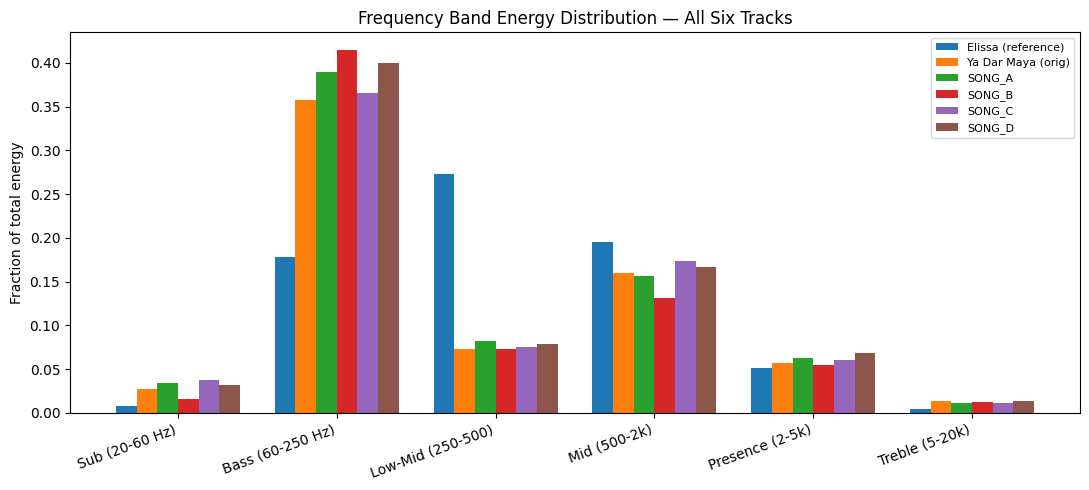

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
band_names = list(BANDS.keys())
x = np.arange(len(band_names))
width = 0.13

for i, (name, path) in enumerate(TRACKS):
    y, sr = librosa.load(path, sr=22050, mono=True)
    ratios = [band_energy_ratio(y, sr, lo, hi) for lo, hi in BANDS.values()]
    ax.bar(x + i * width, ratios, width=width, label=name)

ax.set_xticks(x + width * (len(TRACKS) - 1) / 2)
ax.set_xticklabels(band_names, rotation=20, ha="right")
ax.set_ylabel("Fraction of total energy")
ax.set_title("Frequency Band Energy Distribution — All Six Tracks")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/band_energy_all_tracks.png", dpi=110)
plt.show()

The bars tell the same story as the table: the six tracks are broadly similar in how
they distribute energy across bass/mid/presence/treble. The real differences between
Elissa and the Suno tracks, whatever they are, aren't sitting in this kind of
whole-mix frequency balance.

## F. Preview: the vocal-stem spectral difference Notebook 02 flagged

Now we finally have the tools to actually *look at* the loose thread from Notebook 02,
even though we're not ready to explain it yet. Let's plot Elissa's isolated vocal stem
spectrum against her isolated instrumental stem spectrum, and mark the Low-Mid and
Presence bands.

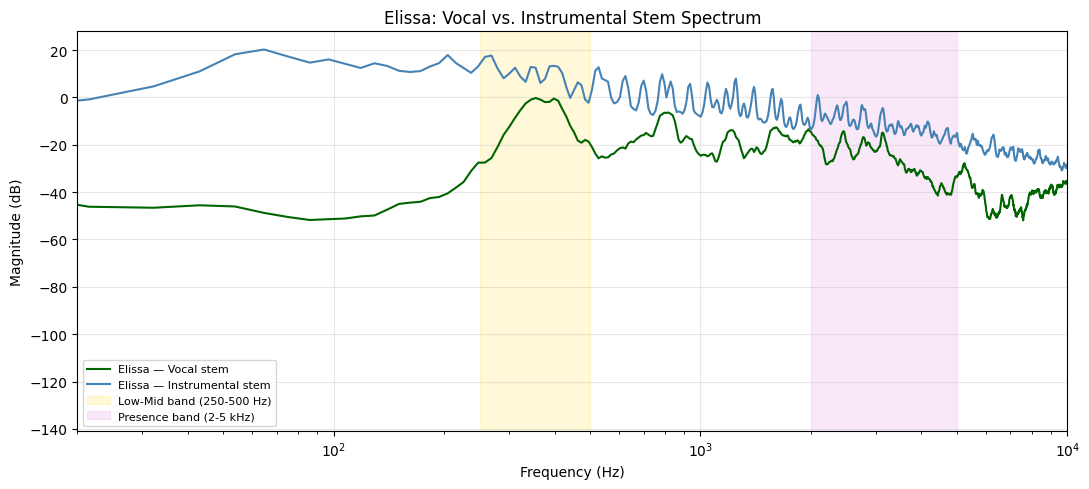

Elissa vocal Low-Mid (250-500Hz) energy share: 11.0%


In [7]:
ELISSA_VOCALS = f"{DATA_DIR}/elisa_maktooba_leek/elisa_maktooba_leek-Vocals.mp3"
ELISSA_INSTR  = f"{DATA_DIR}/elisa_maktooba_leek/elisa_maktooba_leek-Instrumental.mp3"

def spectral_profile(path, sr=22050, n_fft=2048):
    y, _ = librosa.load(path, sr=sr, mono=True)
    S = np.abs(librosa.stft(y, n_fft=n_fft))
    mag = np.median(S, axis=1)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    return freqs, mag

freqs, voc_spec = spectral_profile(ELISSA_VOCALS)
_, inst_spec = spectral_profile(ELISSA_INSTR)

fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogx(freqs, 20 * np.log10(voc_spec + 1e-12), label="Elissa — Vocal stem", color="darkgreen")
ax.semilogx(freqs, 20 * np.log10(inst_spec + 1e-12), label="Elissa — Instrumental stem", color="steelblue")
ax.axvspan(250, 500, color="gold", alpha=0.15, label="Low-Mid band (250-500 Hz)")
ax.axvspan(2000, 5000, color="orchid", alpha=0.15, label="Presence band (2-5 kHz)")
ax.set_xlim(20, 10000)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("Elissa: Vocal vs. Instrumental Stem Spectrum")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/elissa_vocal_vs_instrumental_spectrum.png", dpi=110)
plt.show()

print(f"Elissa vocal Low-Mid (250-500Hz) energy share: {band_energy_ratio(*librosa.load(ELISSA_VOCALS, sr=22050, mono=True), 250, 500):.1%}")

**Elissa's vocal stem concentrates a real, visible chunk of its energy in the Low-Mid
band** — the "body" of a professionally recorded voice. This is the exact observation
Notebook 02 flagged as unexplained. We now have a name for what we're looking at (a
spectral profile, a Low-Mid concentration), but not yet a way to tell whether this
reflects a genuine mixing/vocal-technique difference or an artifact of how cleanly the
separation tool extracted each stem. **That test is what Notebook 04 is for** — this
notebook only gave us the eyes to see the question clearly.

## Self-Check

Try to answer each question yourself before expanding the answer.

<details>
<summary><b>Q1.</b> What's the difference between what a waveform plot shows and what a spectrum plot shows, for the exact same 1 second of audio?</summary>

A waveform plot shows amplitude (loudness) changing moment-to-moment over time. A
spectrum plot ignores time entirely and instead shows how much of each frequency is
present in that chunk, added together. They're two different questions asked of the
same audio: "how loud, when?" vs. "made of which pitches, how much of each?"
</details>

<details>
<summary><b>Q2.</b> Why is a spectrogram described as "adding time back in" to a spectrum?</summary>

A single FFT/spectrum collapses an entire window of audio into one static snapshot — it
can't show how the frequency content changes during that window. A spectrogram computes
many spectra from many short, consecutive windows and stacks them side by side, with time
along one axis, so you can see frequency content evolve, exactly the way a waveform plot
lets you see amplitude evolve.
</details>

<details>
<summary><b>Q3.</b> The "missing presence" hypothesis (Suno tracks lack 2-5 kHz sparkle) turned out to be false. What did the actual data show instead?</summary>

Every Suno track measured equal or slightly higher 2-5 kHz energy than Elissa's
reference mix, not lower. Whatever makes the Suno tracks sound less polished, a simple
deficiency in high-frequency "presence" energy isn't a good explanation for it — that
hypothesis is not supported by the band-energy measurement.
</details>

<details>
<summary><b>Q4.</b> This notebook showed Elissa's vocal has a strong Low-Mid energy concentration that the Suno vocal stems don't — but stopped short of explaining why. What are the (at least) two competing explanations, and why can't this notebook tell them apart yet?</summary>

Either (a) Elissa's actual, professionally recorded and mixed vocal genuinely has more
low-mid "body" than a Suno-generated vocal does, or (b) the AI separation tool extracts
Elissa's natural voice more cleanly than it extracts Suno's synthetic voice, and some of
that apparent low-mid energy is really leftover instrumental bleed rather than true vocal
content. Telling these apart requires auditing the separation tool's accuracy directly
(checking for bleed, reconstruction error, etc.) — a different kind of test than anything
a spectrum or spectrogram alone can show. That's exactly Notebook 04's job.
</details>

## Summary — what you now have

- **Frequency** describes pitch (cycles per second, Hz), a completely different axis from
  loudness (RMS/dB) — a sound is a mixture of many frequencies at once.
- **FFT** turns one chunk of waveform into a spectrum: energy per frequency, with time
  collapsed away.
- **STFT / spectrogram** restores time by stacking many FFTs from consecutive short
  windows — time × frequency × energy (as color), the picture behind every "spectral
  profile" plot elsewhere in this project.
- **Named frequency bands** (Sub, Bass, Low-Mid, Mid, Presence, Treble) let engineers talk
  about *where* energy sits without quoting raw Hz numbers, and let us compute what
  fraction of a signal's energy falls in each band.
- **The presence-band hypothesis was correctly ruled out**: all six tracks carry
  comparable (or higher, for Suno) 2-5 kHz energy — confirmed here with the same
  measurement the early labs used.
- **The Notebook 02 loose thread is now visible, not yet explained**: Elissa's vocal
  stem shows a real Low-Mid energy concentration the Suno vocal stems lack. Whether
  that's a genuine mixing difference or a separation-tool artifact is exactly what
  **Notebook 04** investigates next.